In [1]:
import sys
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from libs.danbooru_client import create_danbooru_client
from libs.character_search import (
    calculate_average_tag_frequency,
    calculate_gender_frequencies,
)

In [3]:
client = create_danbooru_client()

# 读取测试用txt文件（arknights_female_characters.txt）
tags = []
with open("test/arknights_female_characters.txt", "r", encoding="utf-8") as file:
    for line in file:
        tag = line.strip()
        if tag:
            tags.append(tag)
# print(tags)
female_frequencies = []
male_frequencies = []
for tag in tqdm(tags, desc="计算标签频率"):
    female_frequencies.append(
        calculate_average_tag_frequency(tag=tag, tag_list=["girl"])
    )
    male_frequencies.append(calculate_average_tag_frequency(tag=tag, tag_list=["boy"]))

# 保存到csv文件
output_file = "test/frequencies.csv"
if os.path.exists(output_file):
    os.remove(output_file)
with open(output_file, "w", encoding="utf-8") as file:
    file.write("tag,female_frequency,male_frequency\n")
    for i in range(len(tags)):
        file.write(f"{tags[i]},{female_frequencies[i]},{male_frequencies[i]}\n")

计算标签频率: 100%|██████████| 489/489 [06:56<00:00,  1.17it/s]


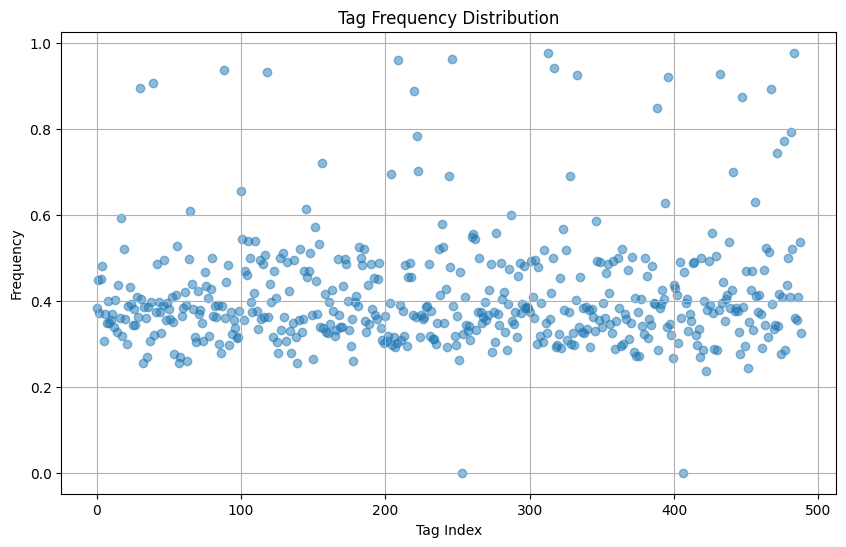

In [ ]:
female_frequencies = []
with open("test/frequencies.csv", "r", encoding="utf-8") as f:
    for line in f:
        female_frequencies.append(float(line.strip()))
# 绘制频率分布图（散点图）
plt.figure(figsize=(10, 6))
plt.scatter(range(len(female_frequencies)), female_frequencies, alpha=0.5)
plt.title("Tag Frequency Distribution")
plt.xlabel("Tag Index")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("test/frequencies_distribution.png")
plt.show()